<div style="text-align:center; color:darkblue; font-size:32px; font-weight:bold;">

Titanic Dataset Analysis Pandas vs SQL
</div>
<br>
<div style="text-align:center; color:gray; font-size:18px;">

<div style="direction:rtl; text-align:right; color:darkblue; font-size:20px; line-height:1.8">

هدف این پروژه، تحلیل دیتاست **Titanic** با استفاده از کتابخانه **Pandas** و همچنین مقایسه نتایج با دستورات **SQL** است. در ابتدا داده‌ها وارد محیط پایتون شده و به DataFrame تبدیل می‌شوند. سپس داده‌ها از نظر مقادیر گمشده، داده‌های تکراری و سایر مشکلات بررسی و پاکسازی خواهند شد. پس از آماده‌سازی داده‌ها، شاخص‌های آمار توصیفی محاسبه شده و نمودارهای مختلف برای تحلیل داده‌ها رسم می‌شوند. در پایان نیز همان تحلیل‌های مهم با استفاده از SQL انجام شده و نتایج با Pandas مقایسه خواهند شد.

</div>

### Import Libraries (وارد کردن کتابخانه‌ها)

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sqlite3

In [9]:
!pip install openml

  Using cached openml-0.15.1-py3-none-any.whl.metadata (10 kB)
  Using cached liac-arff-2.5.0.tar.gz (13 kB)
  Preparing metadata (setup.py): started
  Preparing metadata (setup.py): finished with status 'done'
  Using cached xmltodict-1.0.4-py3-none-any.whl.metadata (14 kB)
  Using cached minio-7.2.20-py3-none-any.whl.metadata (6.5 kB)
   ---------------------------------------- 0.0/1.8 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.8 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.8 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.8 MB ? eta -:--:--
   ----------- ---------------------------- 0.5/1.8 MB 3.9 MB/s eta 0:00:01
   ----------------- ---------------------- 0.8/1.8 MB 2.1 MB/s eta 0:00:01
   ---------------------------------- ----- 1.6/1.8 MB 2.5 MB/s eta 0:00:01
   ---------------------------------------- 1.8/1.8 MB 2.5 MB/s eta 0:00:00
  Created wheel for liac-arff: filename=liac_arff-2.5.0-py3-none-any.whl size=117

  DEPRECATION: Building 'liac-arff' using the legacy setup.py bdist_wheel mechanism, which will be removed in a future version. pip 25.3 will enforce this behaviour change. A possible replacement is to use the standardized build interface by setting the `--use-pep517` option, (possibly combined with `--no-build-isolation`), or adding a `pyproject.toml` file to the source tree of 'liac-arff'. Discussion can be found at https://github.com/pypa/pip/issues/6334


### Load Titanic Dataset (بارگذاری دیتاست تایتانیک)



In [11]:
import openml

dataset = openml.datasets.get_dataset(40945)

df, *_ = dataset.get_data(dataset_format="dataframe")

df.head()

,pclass,survived,name,sex,age,sibsp,parch,ticket,fare,cabin,embarked,boat,body,home.dest
0,1,1,"Allen, Miss. Elisabeth Walton",female,29.0000,0,0,24160,211.3375,B5,S,2,NaN,"St Louis, MO"
1,1,1,"Allison, Master. Hudson Trevor",male,0.9167,1,2,113781,151.5500,C22 C26,S,11,NaN,"Montreal, PQ / Chesterville, ON"
2,1,0,"Allison, Miss. Helen Loraine",female,2.0000,1,2,113781,151.5500,C22 C26,S,None,NaN,"Montreal, PQ / Chesterville, ON"
3,1,0,"Allison, Mr. Hudson Joshua Creighton",male,30.0000,1,2,113781,151.5500,C22 C26,S,None,135.0,"Montreal, PQ / Chesterville, ON"
4,1,0,"Allison, Mrs. Hudson J C (Bessie Waldo Daniels)",female,25.0000,1,2,113781,151.5500,C22 C26,S,None,NaN,"Montreal, PQ / Chesterville, ON"


### Dataset Information (اطلاعات کلی دیتاست)

### Dataset Shape (ابعاد دیتاست)

In [12]:
df.shape

(1309, 14)

### Column's Name (نام ستون ها)

In [13]:
df.columns

Index(['pclass', 'survived', 'name', 'sex', 'age', 'sibsp', 'parch', 'ticket',
       'fare', 'cabin', 'embarked', 'boat', 'body', 'home.dest'],
      dtype='object')

## توضیح ستون‌های دیتاست Titanic

| نام ستون | توضیح |
|----------|-------|
| **pclass** | کلاس بلیت مسافر (1: درجه یک، 2: درجه دو، 3: درجه سه) |
| **survived** | وضعیت نجات (0: فوت شده، 1: نجات یافته) |
| **name** | نام کامل مسافر |
| **sex** | جنسیت مسافر (مرد یا زن) |
| **age** | سن مسافر (بر حسب سال) |
| **sibsp** | تعداد خواهر، برادر یا همسر همراه مسافر |
| **parch** | تعداد والدین یا فرزندان همراه مسافر |
| **ticket** | شماره بلیت |
| **fare** | هزینه پرداختی برای بلیت |
| **cabin** | شماره کابین مسافر |
| **embarked** | بندری که مسافر از آن سوار کشتی شده است (C: Cherbourg، Q: Queenstown، S: Southampton) |
| **boat** | شماره قایق نجات (برای افرادی که نجات یافته‌اند) |
| **body** | شماره شناسایی جسد (برای افرادی که فوت کرده‌اند و جسدشان پیدا شده است) |
| **home.dest** | محل سکونت یا مقصد نهایی مسافر |

<h1 style="color:blue; text-align:center; font-size:40px;">
Pandas Data Analysis
</h1>


In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1309 entries, 0 to 1308
Data columns (total 14 columns):
 #   Column     Non-Null Count  Dtype   
---  ------     --------------  -----   
 0   pclass     1309 non-null   uint8   
 1   survived   1309 non-null   category
 2   name       1309 non-null   object  
 3   sex        1309 non-null   category
 4   age        1046 non-null   float64 
 5   sibsp      1309 non-null   uint8   
 6   parch      1309 non-null   uint8   
 7   ticket     1309 non-null   object  
 8   fare       1308 non-null   float64 
 9   cabin      295 non-null    object  
 10  embarked   1307 non-null   category
 11  boat       486 non-null    object  
 12  body       121 non-null    float64 
 13  home.dest  745 non-null    object  
dtypes: category(3), float64(3), object(5), uint8(3)
memory usage: 90.0+ KB


### Number of Males and Females (تعداد مردان و زنان)

In [16]:
df["sex"].value_counts()

sex
male      843
female    466
Name: count, dtype: int64

### Number of Survivors (تعداد نجات‌یافتگان)

In [17]:
df["survived"].value_counts()

survived
0    809
1    500
Name: count, dtype: int64

### Passenger Class Distribution (توزیع کلاس‌های مسافران)

In [18]:
df["pclass"].value_counts()

pclass
3    709
1    323
2    277
Name: count, dtype: int64

### Embarkation Port Distribution (توزیع بنادر)

In [19]:
df["embarked"].value_counts()

embarked
S    914
C    270
Q    123
Name: count, dtype: int64

### تعداد مردان نجات‌یافته

In [54]:
df[(df["sex"]=="male") & (df["survived"]==1)].shape[0]

161

### تعداد زنان نجات‌یافته

In [55]:
df[(df["sex"]=="female") & (df["survived"]==1)].shape[0]

339

### تعداد مردان فوت‌شده 

In [56]:
df[(df["sex"] == "male") & (df["survived"] == 0)].shape[0]

682

### تعداد زنان فوت‌شده

In [57]:
df[(df["sex"] == "female") & (df["survived"] == 0)].shape[0]

127

### چند نفر از هر کلاس نجات پیدا کردند؟

In [58]:
df.groupby("pclass")["survived"].sum()

pclass
1    200
2    119
3    181
Name: survived, dtype: int64

### افراد زیر ۱۸ سال که نجات پیدا کردند

In [59]:
df[(df["age"]<18) & 
   (df["survived"]==1)].shape[0]

81

### افراد بالای ۶۰ سال که نجات پیدا کردند

In [60]:
df[(df["age"]>60) & 
   (df["survived"]==1)].shape[0]

8

### مسافرانی که تنها سفر کردند و نجات پیدا کردند

In [61]:
df[(df["sibsp"]==0) & 
   (df["parch"]==0) & 
   (df["survived"]==1)].shape[0]

239

### افراد دارای خانواده بیش از 3 نفر

In [62]:
df[(df["sibsp"]+df["parch"]>3)].shape[0]

82

### تعداد افراد هر بندر و وضعیت نجات

In [75]:
df.groupby(["embarked","survived"], observed=True).size().reset_index(name="count")

,embarked,survived,count
0,C,0,120
1,C,1,150
2,Q,0,79
3,Q,1,44
4,S,0,610
5,S,1,306


### کلاس سفر + جنسیت + نجات

In [65]:
df.groupby(["pclass","sex","survived"], observed=True).size()

pclass  sex     survived
1       female  0             5
                1           139
        male    0           118
                1            61
2       female  0            12
                1            94
        male    0           146
                1            25
3       female  0           110
                1           106
        male    0           418
                1            75
dtype: int64

### تعداد نجات یافتگان بر اساس حروف الفبا

In [72]:
df["name_initial"] = df["name"].str[0]    #استخرج حرف اول اسم

In [73]:
df["name_initial"].value_counts()        # تعداد کل افراد بر اساس حرف اول اسم

name_initial
S    125
C    111
M    104
B    103
H     92
A     75
D     72
L     68
P     66
W     61
R     60
G     54
K     49
F     47
T     40
J     39
N     39
O     34
E     17
V     17
I      9
Y      7
d      7
Z      5
v      4
Q      3
U      1
Name: count, dtype: int64

In [71]:
df.groupby("name_initial")["survived"].agg(["count","sum"])

,count,sum
name_initial,,
A,75,26
B,103,48
C,111,44
D,72,35
E,17,4
F,47,18
G,54,15
H,92,42
I,9,3


## Data Cleaning (تمیزکردن داده‌ها)

<h4 style="color:blue;">بررسی مقادیر گمشده (Missing Values)</h4>

In [20]:
df.isnull().sum()

pclass          0
survived        0
name            0
sex             0
age           263
sibsp           0
parch           0
ticket          0
fare            1
cabin        1014
embarked        2
boat          823
body         1188
home.dest     564
dtype: int64

<h4 style="color:blue;">درصد مقادیر گمشده (Missing Values Percentage)</h4>

In [21]:
(df.isnull().sum()/len(df)*100).round(2)

pclass        0.00
survived      0.00
name          0.00
sex           0.00
age          20.09
sibsp         0.00
parch         0.00
ticket        0.00
fare          0.08
cabin        77.46
embarked      0.15
boat         62.87
body         90.76
home.dest    43.09
dtype: float64

<h4 style="color:blue;">بررسی نوع داده‌ها (Data Types)</h4>

In [24]:
df.dtypes

pclass          uint8
survived     category
name           object
sex          category
age           float64
sibsp           uint8
parch           uint8
ticket         object
fare          float64
cabin          object
embarked     category
boat           object
body          float64
home.dest      object
dtype: object

<h4 style="color:blue;">بررسی داده‌های تکراری (Duplicate Values)</h4>

In [23]:
df.duplicated().sum()

np.int64(0)

In [25]:
df[df.duplicated()]

,pclass,survived,name,sex,age,sibsp,parch,ticket,fare,cabin,embarked,boat,body,home.dest


<h4 style="color:blue;">   حذف ستون‌های دارای مقادیر گمشده زیاد</h4>

در این مرحله، ستون‌هایی که تعداد مقادیر گمشده آن‌ها بیشتر از 1000 مورد است حذف می‌شوند، زیرا تعداد داده‌های موجود برای تحلیل این ستون‌ها کافی نیست.

In [32]:
df.drop(columns=["cabin", "body"], inplace=True)

In [38]:
df.drop(columns=["boat"], inplace=True)

<h4 style="color:blue;">جایگزینی مقادیر گمشده</h4>
Numeric → Median  /  
                      Categorical/Text → Mode

In [35]:
df["age"] = df["age"].fillna(df["age"].median())

df["fare"] = df["fare"].fillna(df["fare"].median())

In [36]:
df["embarked"] = df["embarked"].fillna(df["embarked"].mode()[0])

df["home.dest"] = df["home.dest"].fillna(df["home.dest"].mode()[0])

In [39]:
df.isnull().sum()

pclass       0
survived     0
name         0
sex          0
age          0
sibsp        0
parch        0
ticket       0
fare         0
embarked     0
home.dest    0
dtype: int64

## آمار توصیفی (Descriptive Statistics)

In [40]:
df.describe()

,pclass,age,sibsp,parch,fare
count,1309.000000,1309.000000,1309.000000,1309.000000,1309.000000
mean,2.294882,29.503183,0.498854,0.385027,33.281086
std,0.837836,12.905246,1.041658,0.865560,51.741500
min,1.000000,0.166700,0.000000,0.000000,0.000000
25%,2.000000,22.000000,0.000000,0.000000,7.895800
50%,3.000000,28.000000,0.000000,0.000000,14.454200
75%,3.000000,35.000000,1.000000,0.000000,31.275000
max,3.000000,80.000000,8.000000,9.000000,512.329200


In [41]:
df.describe(include="category")

,survived,sex,embarked
count,1309,1309,1309
unique,2,2,3
top,0,male,S
freq,809,843,916


# نمودارها (Data Visualization)

## بررسی توزیع جنسیت مسافران

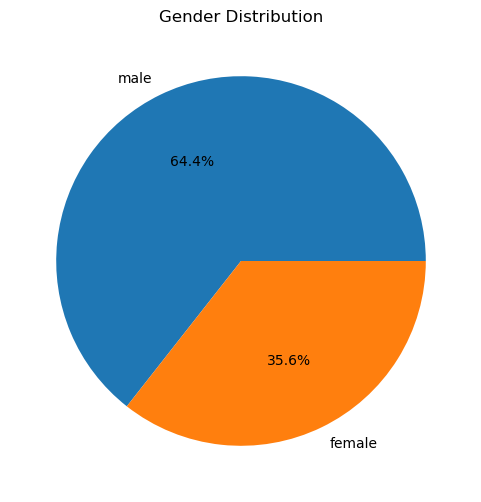

In [77]:
df["sex"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%",
    figsize=(6,6)
)

plt.title("Gender Distribution")
plt.ylabel("")
plt.show()

## نجات‌یافتگان و فوت‌شدگان

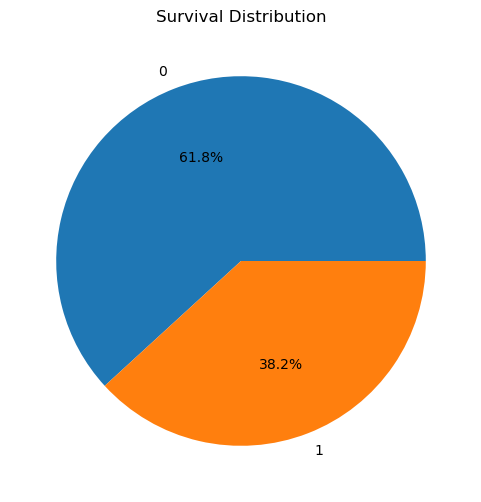

In [78]:
df["survived"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%",
    figsize=(6,6)
)

plt.title("Survival Distribution")
plt.ylabel("")
plt.show()

## سهم هر کلاس سفر

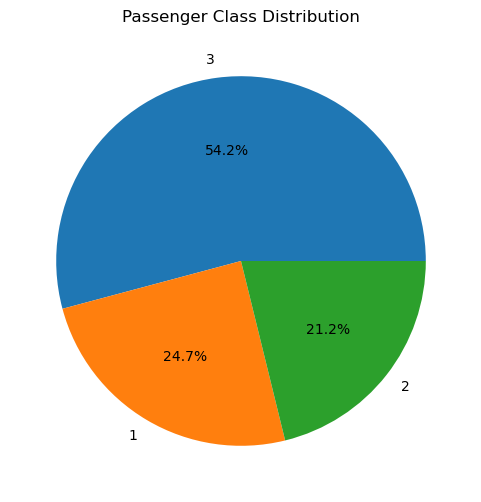

In [79]:
df["pclass"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%",
    figsize=(6,6)
)

plt.title("Passenger Class Distribution")
plt.ylabel("")
plt.show()

## سهم بنادر 

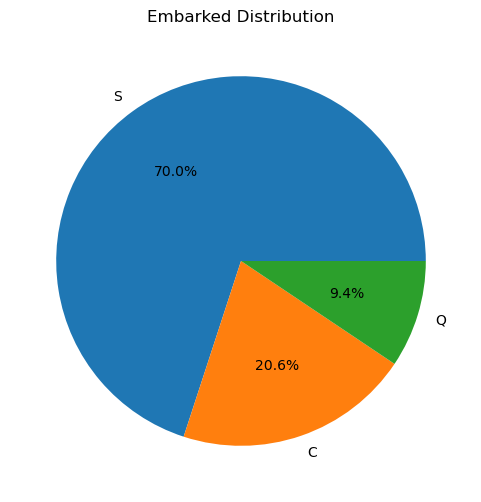

In [80]:
df["embarked"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%",
    figsize=(6,6)
)

plt.title("Embarked Distribution")
plt.ylabel("")
plt.show()

## نجات‌یافته‌ها بر اساس جنسیت

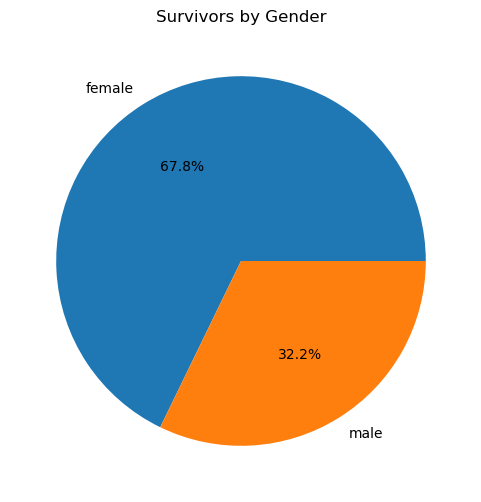

In [81]:
df[df["survived"]==1]["sex"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%",
    figsize=(6,6)
)

plt.title("Survivors by Gender")
plt.ylabel("")
plt.show()

## نجات‌یافته‌ها بر اساس بندر

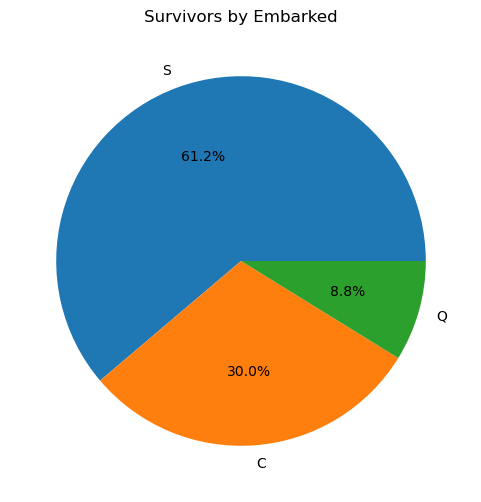

In [82]:
df[df["survived"]==1]["embarked"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%",
    figsize=(6,6)
)

plt.title("Survivors by Embarked")
plt.ylabel("")
plt.show()

## هیستوگرام سن مسافران (Age Distribution)

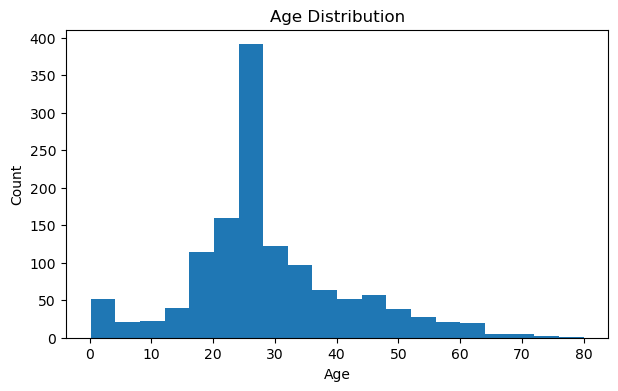

In [83]:
df["age"].plot(
    kind="hist",
    bins=20,
    figsize=(7,4)
)

plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Count")
plt.show()

## هیستوگرام قیمت بلیت (Fare Distribution)

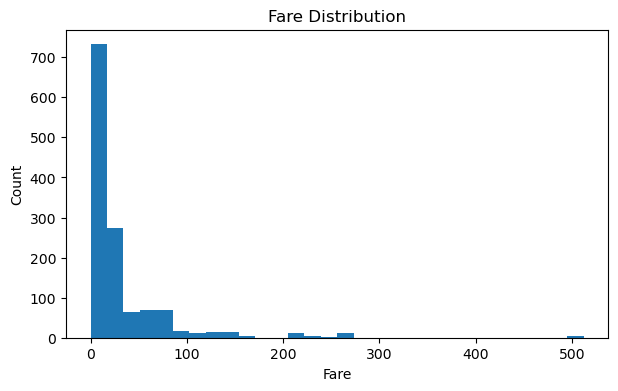

In [84]:
df["fare"].plot(
    kind="hist",
    bins=30,
    figsize=(7,4)
)

plt.title("Fare Distribution")
plt.xlabel("Fare")
plt.ylabel("Count")
plt.show()

## تعداد اعضای خانواده و نجات

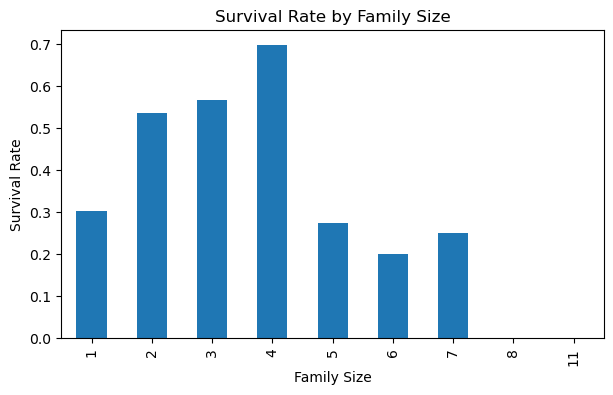

In [88]:
df["family_size"] = df["sibsp"] + df["parch"] + 1

df.groupby("family_size")["survived"].mean().plot(
    kind="bar",
    figsize=(7,4)
)

plt.title("Survival Rate by Family Size")
plt.xlabel("Family Size")
plt.ylabel("Survival Rate")
plt.show()

<h1 style="color:blue; text-align:center; font-size:40px;">
SQL Data Analysis
</h1>


<div dir="rtl" style="text-align:right;">

<h4 style="color:blue;">انتقال DataFrame به پایگاه داده SQLite</h4>

در این مرحله، دیتافریم ایجادشده با استفاده از Pandas به یک پایگاه داده SQLite منتقل می‌شود. با این کار، داده‌ها به صورت یک جدول در پایگاه داده ذخیره شده و از این مرحله به بعد می‌توان تحلیل‌ها را با دستورات SQL نیز انجام داد.

</div>

In [94]:
conn = sqlite3.connect("titanic.db")

df.to_sql(
    "titanic",
    conn,
    if_exists="replace",
    index=False
)

1309

In [95]:
pd.read_sql("SELECT * FROM titanic LIMIT 5;", conn)

,pclass,survived,name,sex,age,sibsp,parch,ticket,fare,embarked,home.dest,name_initial,family_size
0,1,1,"Allen, Miss. Elisabeth Walton",female,29.0000,0,0,24160,211.3375,S,"St Louis, MO",A,1
1,1,1,"Allison, Master. Hudson Trevor",male,0.9167,1,2,113781,151.5500,S,"Montreal, PQ / Chesterville, ON",A,4
2,1,0,"Allison, Miss. Helen Loraine",female,2.0000,1,2,113781,151.5500,S,"Montreal, PQ / Chesterville, ON",A,4
3,1,0,"Allison, Mr. Hudson Joshua Creighton",male,30.0000,1,2,113781,151.5500,S,"Montreal, PQ / Chesterville, ON",A,4
4,1,0,"Allison, Mrs. Hudson J C (Bessie Waldo Daniels)",female,25.0000,1,2,113781,151.5500,S,"Montreal, PQ / Chesterville, ON",A,4


In [96]:
pd.read_sql("""
SELECT *
FROM titanic
LIMIT 5;
""", conn)

,pclass,survived,name,sex,age,sibsp,parch,ticket,fare,embarked,home.dest,name_initial,family_size
0,1,1,"Allen, Miss. Elisabeth Walton",female,29.0000,0,0,24160,211.3375,S,"St Louis, MO",A,1
1,1,1,"Allison, Master. Hudson Trevor",male,0.9167,1,2,113781,151.5500,S,"Montreal, PQ / Chesterville, ON",A,4
2,1,0,"Allison, Miss. Helen Loraine",female,2.0000,1,2,113781,151.5500,S,"Montreal, PQ / Chesterville, ON",A,4
3,1,0,"Allison, Mr. Hudson Joshua Creighton",male,30.0000,1,2,113781,151.5500,S,"Montreal, PQ / Chesterville, ON",A,4
4,1,0,"Allison, Mrs. Hudson J C (Bessie Waldo Daniels)",female,25.0000,1,2,113781,151.5500,S,"Montreal, PQ / Chesterville, ON",A,4


### شمارش تعداد کل مسافران

In [97]:
pd.read_sql("""
SELECT COUNT(*) AS Total_Passengers
FROM titanic;
""", conn)

,Total_Passengers
0,1309


<div style="text-align:left;">

<h4 style="color:blue;">فیلتر کردن داده‌ها  </h4>

</div>

#### تعداد مردان

In [98]:
pd.read_sql("""
SELECT COUNT(*) AS Male_Count
FROM titanic
WHERE sex='male';
""", conn)

,Male_Count
0,843


#### تعداد زنان

In [99]:
pd.read_sql("""
SELECT COUNT(*) AS Female_Count
FROM titanic
WHERE sex='female';
""", conn)

,Female_Count
0,466


#### تعداد نجات‌یافتگان

In [100]:
pd.read_sql("""
SELECT COUNT(*) AS Survivors
FROM titanic
WHERE survived=1;
""", conn)

,Survivors
0,500


#### تعداد فوت‌شدگان

In [101]:
pd.read_sql("""
SELECT COUNT(*) AS Died
FROM titanic
WHERE survived=0;
""", conn)

,Died
0,809


#### مردان و زنان نجات یافته

In [103]:
pd.read_sql("""
SELECT sex, COUNT(*) AS Survivor_Count
FROM titanic
WHERE survived = 1
GROUP BY sex;
""", conn)

,sex,Survivor_Count
0,female,339
1,male,161


#### کودکان زیر ۱۸ سال که نجات پیدا کردند

In [104]:
pd.read_sql("""
SELECT COUNT(*) AS Children_Survivors
FROM titanic
WHERE age < 18 AND survived = 1;
""", conn)

,Children_Survivors
0,81


#### زنان بالای ۶۰ سال

In [105]:
pd.read_sql("""
SELECT COUNT(*) AS Elderly_Women
FROM titanic
WHERE age > 60 AND sex = 'female';
""", conn)

,Elderly_Women
0,7


#### مردان کلاس اول که نجات پیدا کردند

In [106]:
pd.read_sql("""
SELECT COUNT(*) AS FirstClass_Male_Survivors
FROM titanic
WHERE sex = 'male'
AND pclass = 1
AND survived = 1;
""", conn)

,FirstClass_Male_Survivors
0,61


#### افرادی که تنها سفر کرده‌اند و نجات یافته‌اند

In [107]:
pd.read_sql("""
SELECT COUNT(*) AS Solo_Survivors
FROM titanic
WHERE sibsp = 0
AND parch = 0
AND survived = 1;
""", conn)

,Solo_Survivors
0,239


#### زنان یا کودکان نجات‌یافته

In [108]:
pd.read_sql("""
SELECT COUNT(*) AS Women_Or_Children
FROM titanic
WHERE survived = 1
AND (sex = 'female' OR age < 18);
""", conn)

,Women_Or_Children
0,370


<div style="text-align:left;">

<h4 style="color:blue;">گروه‌بندی داده‌ها    </h4>

</div>

#### تعداد افراد هر جنسیت

In [109]:
pd.read_sql("""
SELECT sex, COUNT(*) AS Total
FROM titanic
GROUP BY sex;
""", conn)

,sex,Total
0,female,466
1,male,843


#### تعداد افراد هر کلاس سفر

In [111]:
pd.read_sql("""
SELECT pclass, COUNT(*) AS Total
FROM titanic
GROUP BY pclass;
""", conn)

,pclass,Total
0,1,323
1,2,277
2,3,709


#### تعداد افراد هر بندر

In [112]:
pd.read_sql("""
SELECT embarked, COUNT(*) AS Total
FROM titanic
GROUP BY embarked;
""", conn)

,embarked,Total
0,C,270
1,Q,123
2,S,916


#### میانگین سن مردان و زنان

In [113]:
pd.read_sql("""
SELECT sex, AVG(age) AS Average_Age
FROM titanic
GROUP BY sex;
""", conn)

,sex,Average_Age
0,female,28.572067
1,male,30.017892


#### میانگین قیمت بلیت در هر کلاس سفر

In [114]:
pd.read_sql("""
SELECT pclass, AVG(fare) AS Average_Fare
FROM titanic
GROUP BY pclass;
""", conn)

,pclass,Average_Fare
0,1,87.508992
1,2,21.179196
2,3,13.304513


#### تعداد نجات‌یافته‌ها در هر کلاس

In [115]:
pd.read_sql("""
SELECT pclass, COUNT(*) AS Survivors
FROM titanic
WHERE survived = 1
GROUP BY pclass;
""", conn)

,pclass,Survivors
0,1,200
1,2,119
2,3,181


#### تعداد مردان و زنان در هر کلاس

In [116]:
pd.read_sql("""
SELECT pclass, sex, COUNT(*) AS Total
FROM titanic
GROUP BY pclass, sex;
""", conn)

,pclass,sex,Total
0,1,female,144
1,1,male,179
2,2,female,106
3,2,male,171
4,3,female,216
5,3,male,493


#### میانگین سن در هر کلاس

In [117]:
pd.read_sql("""
SELECT pclass, AVG(age) AS Average_Age
FROM titanic
GROUP BY pclass;
""", conn)

,pclass,Average_Age
0,1,37.812436
1,2,29.419675
2,3,25.750353


#### تعداد نجات‌یافتگان و فوت‌شدگان بر اساس جنسیت

In [118]:
pd.read_sql("""
SELECT
    sex,
    survived,
    COUNT(*) AS Total
FROM titanic
GROUP BY sex, survived;
""", conn)

,sex,survived,Total
0,female,0,127
1,female,1,339
2,male,0,682
3,male,1,161


<div style="text-align:left;">

<h4 style="color:blue;"> Query اجرای  </h4>

</div>

#### نمایش ۵ سطر اول جدول

In [123]:
pd.read_sql("""
SELECT *
FROM titanic
LIMIT 5;
""", conn)

,pclass,survived,name,sex,age,sibsp,parch,ticket,fare,embarked,home.dest,name_initial,family_size
0,1,1,"Allen, Miss. Elisabeth Walton",female,29.0000,0,0,24160,211.3375,S,"St Louis, MO",A,1
1,1,1,"Allison, Master. Hudson Trevor",male,0.9167,1,2,113781,151.5500,S,"Montreal, PQ / Chesterville, ON",A,4
2,1,0,"Allison, Miss. Helen Loraine",female,2.0000,1,2,113781,151.5500,S,"Montreal, PQ / Chesterville, ON",A,4
3,1,0,"Allison, Mr. Hudson Joshua Creighton",male,30.0000,1,2,113781,151.5500,S,"Montreal, PQ / Chesterville, ON",A,4
4,1,0,"Allison, Mrs. Hudson J C (Bessie Waldo Daniels)",female,25.0000,1,2,113781,151.5500,S,"Montreal, PQ / Chesterville, ON",A,4


#### نمایش ۱۰ نفری که بیشترین کرایه را پرداخت کرده‌اند

In [124]:
pd.read_sql("""
SELECT name, fare
FROM titanic
ORDER BY fare DESC
LIMIT 10;
""", conn)

,name,fare
0,"Cardeza, Mr. Thomas Drake Martinez",512.3292
1,"Cardeza, Mrs. James Warburton Martinez (Charlo...",512.3292
2,"Lesurer, Mr. Gustave J",512.3292
3,"Ward, Miss. Anna",512.3292
4,"Fortune, Miss. Alice Elizabeth",263.0000
5,"Fortune, Miss. Ethel Flora",263.0000
6,"Fortune, Miss. Mabel Helen",263.0000
7,"Fortune, Mr. Charles Alexander",263.0000
8,"Fortune, Mr. Mark",263.0000
9,"Fortune, Mrs. Mark (Mary McDougald)",263.0000


#### نمایش ۱۰ نفر با کمترین سن

In [125]:
pd.read_sql("""
SELECT name, age
FROM titanic
ORDER BY age ASC
LIMIT 10;
""", conn)

,name,age
0,"Dean, Miss. Elizabeth Gladys 'Millvina'",0.1667
1,"Danbom, Master. Gilbert Sigvard Emanuel",0.3333
2,"Thomas, Master. Assad Alexander",0.4167
3,"Hamalainen, Master. Viljo",0.6667
4,"Baclini, Miss. Eugenie",0.7500
5,"Baclini, Miss. Helene Barbara",0.7500
6,"Peacock, Master. Alfred Edward",0.7500
7,"Caldwell, Master. Alden Gates",0.8333
8,"Richards, Master. George Sibley",0.8333
9,"Aks, Master. Philip Frank",0.8333


#### نمایش ۵ نفر مسن‌تر

In [126]:
pd.read_sql("""
SELECT name, age
FROM titanic
ORDER BY age DESC
LIMIT 5;
""", conn)

,name,age
0,"Barkworth, Mr. Algernon Henry Wilson",80.0
1,"Cavendish, Mrs. Tyrell William (Julia Florence...",76.0
2,"Svensson, Mr. Johan",74.0
3,"Artagaveytia, Mr. Ramon",71.0
4,"Goldschmidt, Mr. George B",71.0


#### نمایش اسامی افرادی که از بندر Southampton سوار شده‌اند

In [127]:
pd.read_sql("""
SELECT name
FROM titanic
WHERE embarked='S';
""", conn)

,name
0,"Allen, Miss. Elisabeth Walton"
1,"Allison, Master. Hudson Trevor"
2,"Allison, Miss. Helen Loraine"
3,"Allison, Mr. Hudson Joshua Creighton"
4,"Allison, Mrs. Hudson J C (Bessie Waldo Daniels)"
5,"Anderson, Mr. Harry"
6,"Andrews, Miss. Kornelia Theodosia"
7,"Andrews, Mr. Thomas Jr"
8,"Appleton, Mrs. Edward Dale (Charlotte Lamson)"
9,"Barber, Miss. Ellen 'Nellie'"


#### نمایش افرادی که خانواده بزرگ بیش از سه نفری داشتند

In [128]:
pd.read_sql("""
SELECT name,
       sibsp,
       parch
FROM titanic
WHERE sibsp+parch>3;
""", conn)

,name,sibsp,parch
0,"Fortune, Miss. Alice Elizabeth",3,2
1,"Fortune, Miss. Ethel Flora",3,2
2,"Fortune, Miss. Mabel Helen",3,2
3,"Fortune, Mr. Charles Alexander",3,2
4,"Fortune, Mr. Mark",1,4
5,"Fortune, Mrs. Mark (Mary McDougald)",1,4
6,"Ryerson, Master. John Borie",2,2
7,"Ryerson, Miss. Emily Borie",2,2
8,"Ryerson, Miss. Susan Parker 'Suzette'",2,2
9,"Ryerson, Mr. Arthur Larned",1,3


In [129]:
conn.close()